## Import Libraries

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## Adding Dataset Path

In [2]:
DATASET_PATH = r"E:\LnT-Task\Task-2\flowers"

## Loading Dataset

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 4317 files belonging to 5 classes.


## Check Classes

In [4]:
class_names = dataset.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


## Split Dataset

1) Training
2) Validation
3) Testing

In [8]:
dataset_size = tf.data.experimental.cardinality(dataset).numpy()

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

train_dataset = dataset.take(train_size)

remaining = dataset.skip(train_size)

val_dataset = remaining.take(val_size)
test_dataset = remaining.skip(val_size)

print("Total batches:", dataset_size)
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy(),"        70% -> Training")
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy(),"      15% -> Validation")
print("Testing batches:", tf.data.experimental.cardinality(test_dataset).numpy(),"         15% -> Testing")

Total batches: 135
Training batches: 94         70% -> Training
Validation batches: 20       15% -> Validation
Testing batches: 21          15% -> Testing


## Preprocess Images

In [9]:
def preprocess_images(images, labels):
    images = preprocess_input(images)
    return images, labels

train_dataset = train_dataset.map(preprocess_images)
val_dataset = val_dataset.map(preprocess_images)
test_dataset = test_dataset.map(preprocess_images)

## Improve Dataset Performance

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

## Load Pretrained VGG16

In [11]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step


## Freeze VGG16 Layers

In [12]:
base_model.trainable = False

## Add Our Classification Layers

In [13]:
model = models.Sequential([
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    
    layers.Dropout(0.3),
    
    layers.Dense(5, activation="softmax")
])

## Model Summary

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,780,997 (56.39 MB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile Model

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Train VGG16 Model

In [16]:
start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

training_time = time.time() - start_time

print("Training Time:", training_time, "seconds")

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 757s 8s/step - accuracy: 0.6755 - loss: 1.5153 - val_accuracy: 0.8313 - val_loss: 0.5097
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 864s 9s/step - accuracy: 0.8235 - loss: 0.5248 - val_accuracy: 0.8562 - val_loss: 0.4732
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 737s 8s/step - accuracy: 0.8617 - loss: 0.3621 - val_accuracy: 0.8687 - val_loss: 0.4228
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 669s 7s/step - accuracy: 0.9053 - loss: 0.2814 - val_accuracy: 0.8953 - val_loss: 0.3794
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 664s 7s/step - accuracy: 0.9136 - loss: 0.2282 - val_accuracy: 0.9078 - val_loss: 0.2976
Training Time: 3691.4188306331635 seconds


## Accuracy

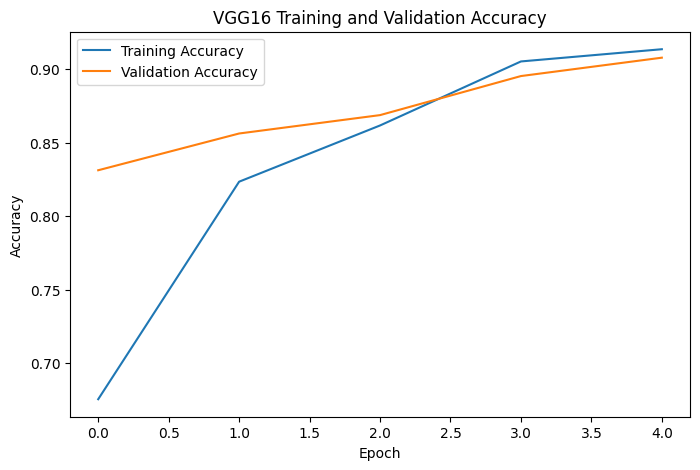

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Training and Validation Accuracy")
plt.legend()

plt.show()

## Loss

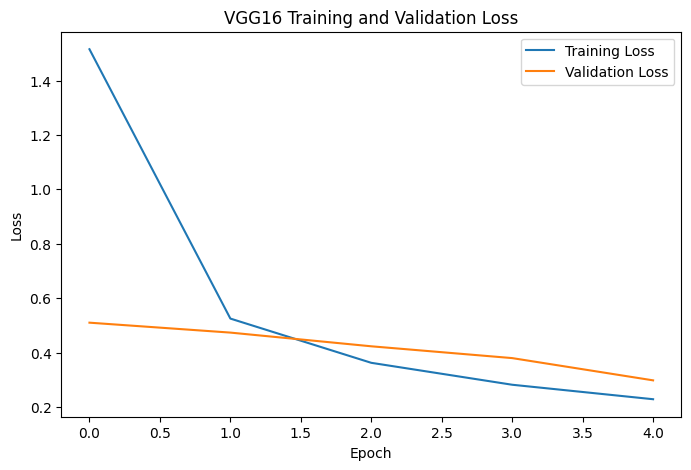

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Training and Validation Loss")
plt.legend()

plt.show()

## Evaluate Model

In [19]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

21/21 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.8670 - loss: 0.4197
Test Loss: 0.41969993710517883
Test Accuracy: 0.8669655919075012
Test Accuracy (%): 86.69655919075012


## Make Predictions

In [20]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

## Classification Report

In [21]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       daisy       0.82      0.85      0.83       113
   dandelion       0.92      0.88      0.90       165
        rose       0.89      0.74      0.81       103
   sunflower       0.86      0.91      0.89       125
       tulip       0.84      0.91      0.87       163

    accuracy                           0.87       669
   macro avg       0.87      0.86      0.86       669
weighted avg       0.87      0.87      0.87       669



## Confusion Matrix

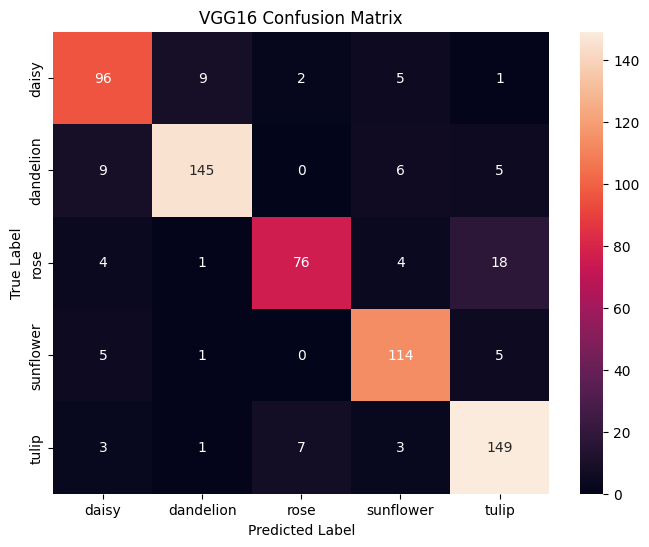

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("VGG16 Confusion Matrix")

plt.show()

## Save VGG16 Model

In [23]:
model.save("vgg16_flowers_model.keras")

## Result

In [24]:
print("Model: VGG16 Transfer Learning")
print("Dataset: Flowers Recognition")
print("Number of Classes:", len(class_names))
print("Test Accuracy:", test_accuracy * 100, "%")
print("Training Time:", training_time, "seconds")

Model: VGG16 Transfer Learning
Dataset: Flowers Recognition
Number of Classes: 5
Test Accuracy: 86.69655919075012 %
Training Time: 3691.4188306331635 seconds
